In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


In [2]:
solutionsPath = Path("data/solutions")

In [3]:
solutions = {}
for file_path in solutionsPath.glob("*.txt"):
    with open(file_path, "r") as file:
        solutions[file_path.name] = [int(file.strip()) for file in file.readlines()]

In [4]:
goodSolutionsPath = Path("data/goodSolutions")

In [5]:
goodSolutions = {}
for file_path in goodSolutionsPath.glob("*.txt"):
    with open(file_path, "r") as file:
        goodSolutions[file_path.name] = [int(file.strip()) for file in file.readlines()]

In [6]:
goodSolutions.__len__()

2

In [7]:
solutions.__len__()

2000

In [8]:
solutions['DataA_0_Greedy_SwapEdges.txt'][1:].__len__()

152

In [9]:
solutionNodeSets = {}
for key, solution in solutions.items():
    solutionNodeSets[key] = set(solution[1:])

In [10]:
solutionNodeSets['DataA_0_Greedy_SwapEdges.txt'].__len__()

152

In [11]:
goodSolutionNodeSets = {}
for key, solution in goodSolutions.items():
    goodSolutionNodeSets[key] = set(solution[1:])

In [12]:
goodSolutionNodeSets['DataA_ILS_ILS.txt'].__len__()

142

In [13]:
solutionEdgeSets = {}
for key, solution in solutions.items():
    nodes = solution[1:]
    edges = set([(nodes[-1],nodes[0]), (nodes[0], nodes[-1])])
    edges.update((nodes[i-1], nodes[i]) for i in range(1,len(nodes)))
    edges.update((nodes[i], nodes[i-1]) for i in range(1,len(nodes)))
    solutionEdgeSets[key] = edges

In [14]:
solutionEdgeSets['DataA_0_Greedy_SwapEdges.txt'].__len__()

304

In [15]:
goodSolutionEdgeSets = {}
for key, solution in goodSolutions.items():
    nodes = solution[1:]
    edges = set([(nodes[-1],nodes[0]), (nodes[0], nodes[-1])])
    edges.update((nodes[i-1], nodes[i]) for i in range(1,len(nodes)))
    edges.update((nodes[i], nodes[i-1]) for i in range(1,len(nodes)))
    goodSolutionEdgeSets[key] = edges

In [16]:
goodSolutionEdgeSets['DataA_ILS_ILS.txt'].__len__()

284

In [17]:
similarityIndex1 = {}
similarityIndex2 = {}
for key, solution in solutions.items():
    if(key.startswith("DataA")):
        similarityIndex1[key] = sum([len(solutionNodeSets[key].intersection(solutionNodeSets[i])) for i in solutionNodeSets.keys() if key != i and i.startswith("DataA")]) / 999.0
        similarityIndex2[key] = sum([len(solutionEdgeSets[key].intersection(solutionEdgeSets[i])) for i in solutionEdgeSets.keys() if key != i and i.startswith("DataA")]) / 999.0
    else:
        similarityIndex1[key] = sum([len(solutionNodeSets[key].intersection(solutionNodeSets[i])) for i in solutionNodeSets.keys() if key != i and i.startswith("DataB")]) / 999.0
        similarityIndex2[key] = sum([len(solutionEdgeSets[key].intersection(solutionEdgeSets[i])) for i in solutionEdgeSets.keys() if key != i and i.startswith("DataB")]) / 999.0

In [18]:
goodSolutions.keys()

dict_keys(['DataA_ILS_ILS.txt', 'DataB_ILS_ILS.txt'])

In [19]:
goodSimilarityIndex1 = {}
goodSimilarityIndex2 = {}
for key, solution in solutions.items():
    if(key.startswith("DataA")):
        goodSimilarityIndex1[key] = len(solutionNodeSets[key].intersection(goodSolutionNodeSets["DataA_ILS_ILS.txt"]))
        goodSimilarityIndex2[key] = len(solutionEdgeSets[key].intersection(goodSolutionEdgeSets["DataA_ILS_ILS.txt"]))
    else:
        goodSimilarityIndex1[key] = len(solutionNodeSets[key].intersection(goodSolutionNodeSets["DataB_ILS_ILS.txt"]))
        goodSimilarityIndex2[key] = len(solutionEdgeSets[key].intersection(goodSolutionEdgeSets["DataB_ILS_ILS.txt"]))


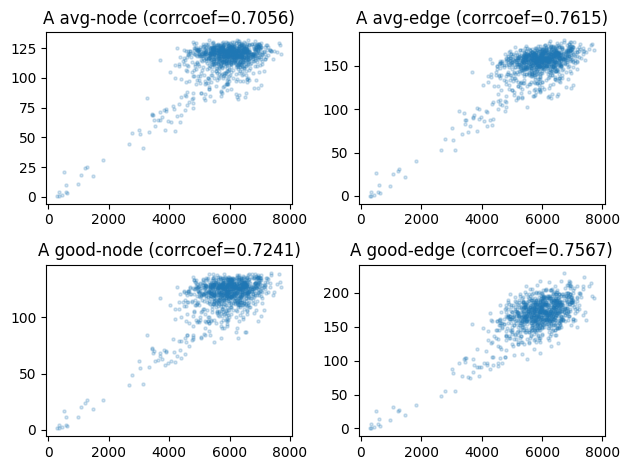

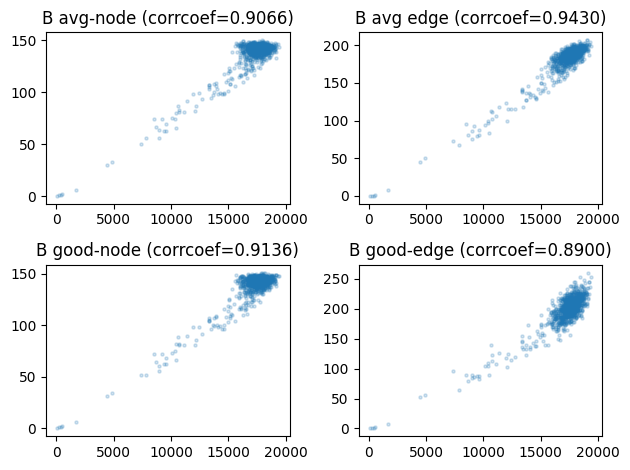

In [ ]:
scoresA = [solution[0] for key, solution in solutions.items() if key.startswith("DataA")]
scoresB = [solution[0] for key, solution in solutions.items() if key.startswith("DataB")]

similarities1A = [similarityIndex1[key] for key, _ in solutions.items() if key.startswith("DataA")]
similarities1B = [similarityIndex1[key] for key, _ in solutions.items() if key.startswith("DataB")]
similarities2A = [similarityIndex2[key] for key, _ in solutions.items() if key.startswith("DataA")]
similarities2B = [similarityIndex2[key] for key, _ in solutions.items() if key.startswith("DataB")]

goodSimilarities1A = [goodSimilarityIndex1[key] for key, _ in solutions.items() if key.startswith("DataA")]
goodSimilarities1B = [goodSimilarityIndex1[key] for key, _ in solutions.items() if key.startswith("DataB")]
goodSimilarities2A = [goodSimilarityIndex2[key] for key, _ in solutions.items() if key.startswith("DataA")]
goodSimilarities2B = [goodSimilarityIndex2[key] for key, _ in solutions.items() if key.startswith("DataB")]

similiaritiesA = {
    "avg-node": similarities1A,
    "avg-edge": similarities2A,
    "good-node": goodSimilarities1A,
    "good-edge": goodSimilarities2A,
}
similiaritiesB = {
    "avg-node": similarities1B,
    "avg edge": similarities2B,
    "good-node": goodSimilarities1B,
    "good-edge": goodSimilarities2B,
}

data = {
    "A" : (scoresA, similiaritiesA),
    "B" : (scoresB, similiaritiesB)
}

for instance, plot_data in data.items():
    x, ys = plot_data
    i = 1
    # plt.figure(figsize=(15,15))
    plt.subplots(2,2)
    for method, y in ys.items():
        corrcoef = np.corrcoef(x, y)[0,1]
        plt.subplot(2,2,i)
        plt.title(f"{instance} {method} (corrcoef={corrcoef:.4f})")
        plt.scatter(x, y, alpha=0.2, s=5)
        i+=1
        plt.tight_layout()
    plt.show()

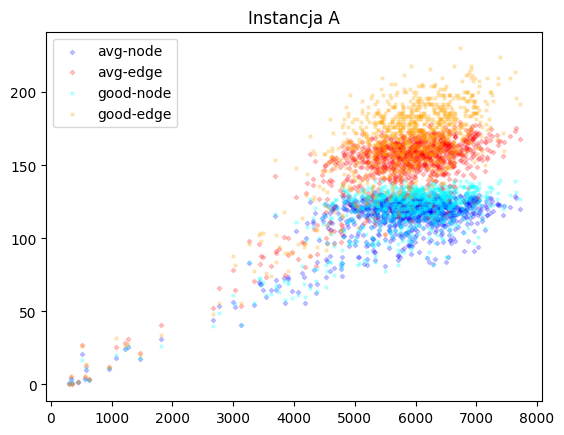

In [35]:
plt.title("Instancja A")
plt.scatter(scoresA, similarities1A, label="avg-node", marker="D", color="blue", alpha=0.2, s=5)
plt.scatter(scoresA, similarities2A, label="avg-edge", marker="D", color="red", alpha=0.2, s=5)
plt.scatter(scoresA, goodSimilarities1A, label="good-node", marker="X", color="cyan", alpha=0.2, s=5)
plt.scatter(scoresA, goodSimilarities2A, label="good-edge", marker="X", color="orange", alpha=0.2, s=5)
plt.legend()

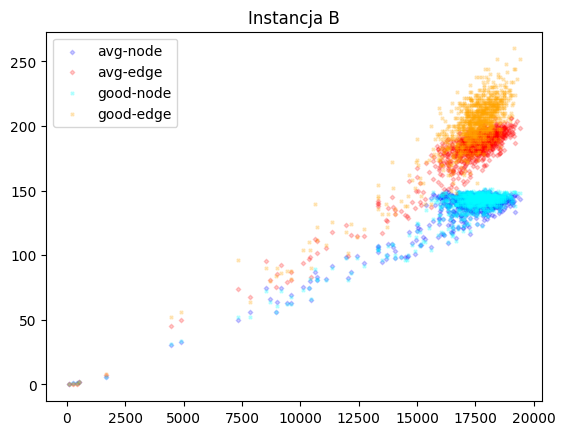

In [34]:


plt.title("Instancja B")
plt.scatter(scoresB, similarities1B, label="avg-node", marker="D", color="blue", alpha=0.2, s=5)
plt.scatter(scoresB, similarities2B, label="avg-edge", marker="D", color="red", alpha=0.2, s=5)
plt.scatter(scoresB, goodSimilarities1B, label="good-node", marker="X", color="cyan", alpha=0.2, s=5)
plt.scatter(scoresB, goodSimilarities2B, label="good-edge", marker="X", color="orange", alpha=0.2, s=5)
plt.legend()

In [ ]:
len(solutions["DataB_470_Greedy_SwapEdges.txt"][1:])

151

Normalized

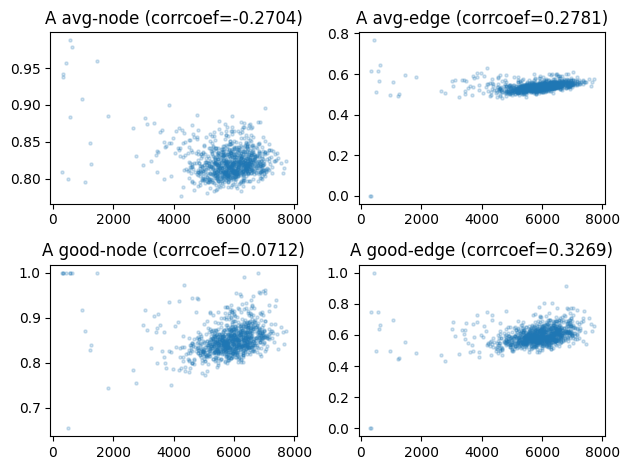

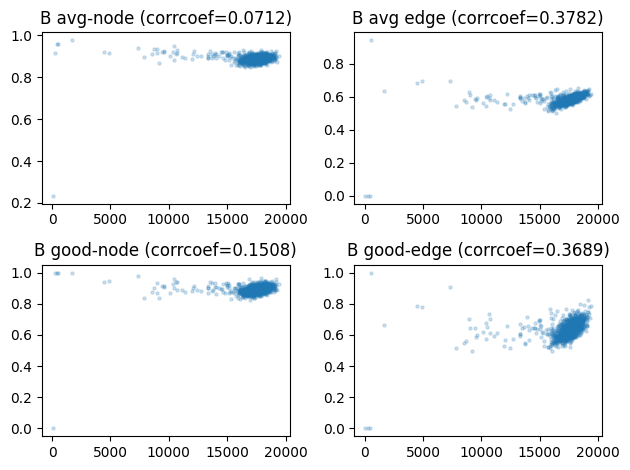

In [33]:
scoresA = [solution[0] for key, solution in solutions.items() if key.startswith("DataA")]
scoresB = [solution[0] for key, solution in solutions.items() if key.startswith("DataB")]

similarities1A = [similarityIndex1[key] / len(solutionNodeSets[key]) for key, _ in solutions.items() if key.startswith("DataA")]
similarities1B = [similarityIndex1[key] / len(solutionNodeSets[key]) for key, _ in solutions.items() if key.startswith("DataB")]
similarities2A = [similarityIndex2[key] / len(solutionEdgeSets[key]) for key, _ in solutions.items() if key.startswith("DataA")]
similarities2B = [similarityIndex2[key] / len(solutionEdgeSets[key]) for key, _ in solutions.items() if key.startswith("DataB")]

goodSimilarities1A = [goodSimilarityIndex1[key] / len(solutionNodeSets[key]) for key, _ in solutions.items() if key.startswith("DataA")]
goodSimilarities1B = [goodSimilarityIndex1[key] / len(solutionNodeSets[key]) for key, _ in solutions.items() if key.startswith("DataB")]
goodSimilarities2A = [goodSimilarityIndex2[key] / len(solutionEdgeSets[key]) for key, _ in solutions.items() if key.startswith("DataA")]
goodSimilarities2B = [goodSimilarityIndex2[key] / len(solutionEdgeSets[key]) for key, _ in solutions.items() if key.startswith("DataB")]

similiaritiesA = {
    "avg-node": similarities1A,
    "avg-edge": similarities2A,
    "good-node": goodSimilarities1A,
    "good-edge": goodSimilarities2A,
}
similiaritiesB = {
    "avg-node": similarities1B,
    "avg edge": similarities2B,
    "good-node": goodSimilarities1B,
    "good-edge": goodSimilarities2B,
}

data = {
    "A" : (scoresA, similiaritiesA),
    "B" : (scoresB, similiaritiesB)
}

for instance, plot_data in data.items():
    x, ys = plot_data
    i = 1
    # plt.figure(figsize=(15,15))
    plt.subplots(2,2)
    for method, y in ys.items():
        corrcoef = np.corrcoef(x, y)[0,1]
        plt.subplot(2,2,i)
        plt.title(f"{instance} {method} (corrcoef={corrcoef:.4f})")
        plt.scatter(x, y, alpha=0.2, s=5)
        i+=1
        plt.tight_layout()
    plt.show()

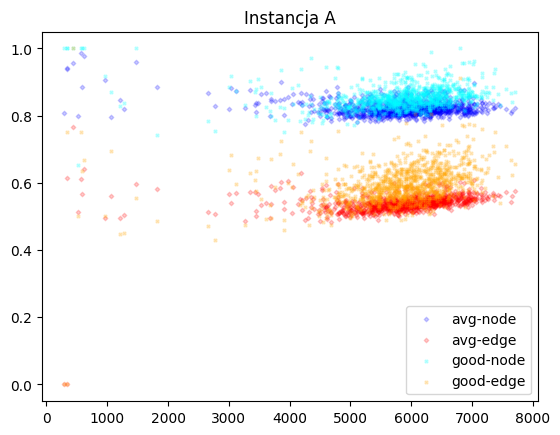

In [34]:
plt.title("Instancja A")
plt.scatter(scoresA, similarities1A, label="avg-node", marker="D", color="blue", alpha=0.2, s=5)
plt.scatter(scoresA, similarities2A, label="avg-edge", marker="D", color="red", alpha=0.2, s=5)
plt.scatter(scoresA, goodSimilarities1A, label="good-node", marker="X", color="cyan", alpha=0.2, s=5)
plt.scatter(scoresA, goodSimilarities2A, label="good-edge", marker="X", color="orange", alpha=0.2, s=5)
plt.legend()

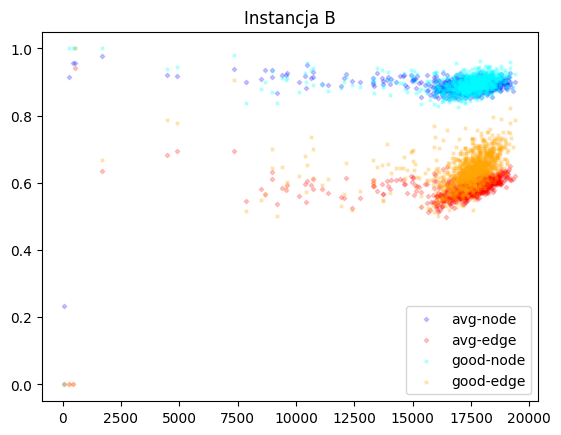

In [ ]:
plt.title("Instancja B")
plt.scatter(scoresB, similarities1B, label="avg-node", marker="D", color="blue", alpha=0.2, s=5)
plt.scatter(scoresB, similarities2B, label="avg-edge", marker="D", color="red", alpha=0.2, s=5)
plt.scatter(scoresB, goodSimilarities1B, label="good-node", marker="X", color="cyan", alpha=0.2, s=5)
plt.scatter(scoresB, goodSimilarities2B, label="good-edge", marker="X", color="orange", alpha=0.2, s=5)
plt.legend()

In [41]:
import pandas as pd

df = pd.DataFrame()

keys = [i for i in solutions.keys()]

df["keys"] = keys
df["values"] = [solutions[i][0] for i in keys]

In [46]:
df_sorted = df.sort_values("values", ascending=False)

In [58]:
a_filtered = df_sorted[df_sorted["keys"].str.startswith("DataA")]["keys"].head(950).tolist()
b_filtered = df_sorted[df_sorted["keys"].str.startswith("DataB")]["keys"].head(950).tolist()

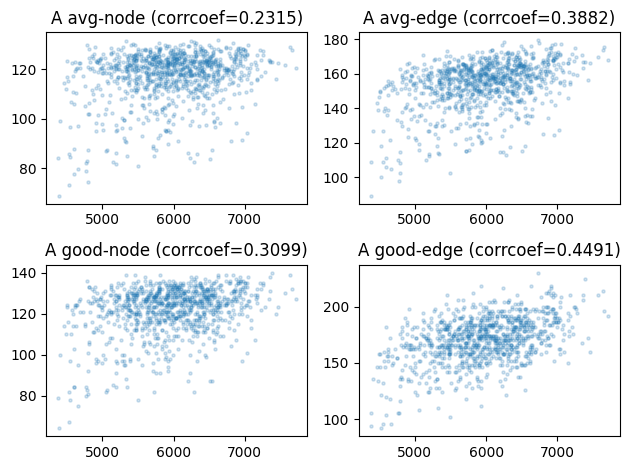

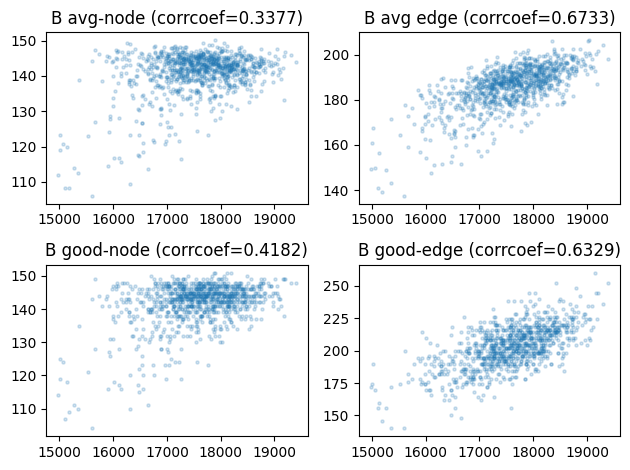

In [62]:
scoresA = [solutions[key][0] for key in a_filtered]
scoresB = [solutions[key][0] for key in b_filtered]

similarities1A = [similarityIndex1[key] for key in a_filtered]
similarities1B = [similarityIndex1[key] for key in b_filtered]
similarities2A = [similarityIndex2[key] for key in a_filtered]
similarities2B = [similarityIndex2[key] for key in b_filtered]

goodSimilarities1A = [goodSimilarityIndex1[key] for key in a_filtered]
goodSimilarities1B = [goodSimilarityIndex1[key] for key in b_filtered]
goodSimilarities2A = [goodSimilarityIndex2[key] for key in a_filtered]
goodSimilarities2B = [goodSimilarityIndex2[key] for key in b_filtered]

similiaritiesA = {
    "avg-node": similarities1A,
    "avg-edge": similarities2A,
    "good-node": goodSimilarities1A,
    "good-edge": goodSimilarities2A,
}
similiaritiesB = {
    "avg-node": similarities1B,
    "avg edge": similarities2B,
    "good-node": goodSimilarities1B,
    "good-edge": goodSimilarities2B,
}

data = {
    "A" : (scoresA, similiaritiesA),
    "B" : (scoresB, similiaritiesB)
}

for instance, plot_data in data.items():
    x, ys = plot_data
    i = 1
    # plt.figure(figsize=(15,15))
    plt.subplots(2,2)
    for method, y in ys.items():
        corrcoef = np.corrcoef(x, y)[0,1]
        plt.subplot(2,2,i)
        plt.title(f"{instance} {method} (corrcoef={corrcoef:.4f})")
        plt.scatter(x, y, alpha=0.2, s=5)
        i+=1
        plt.tight_layout()
    plt.show()

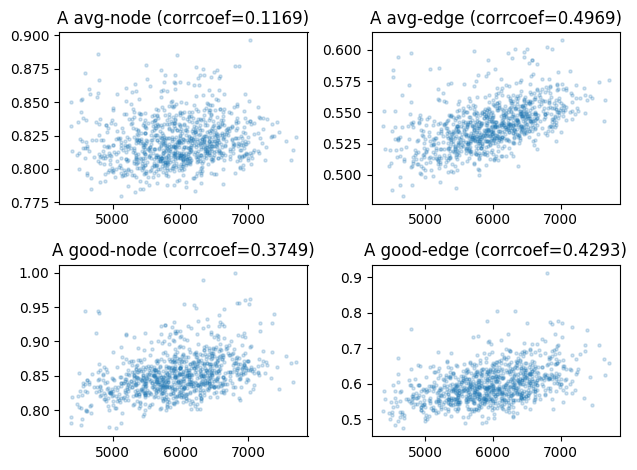

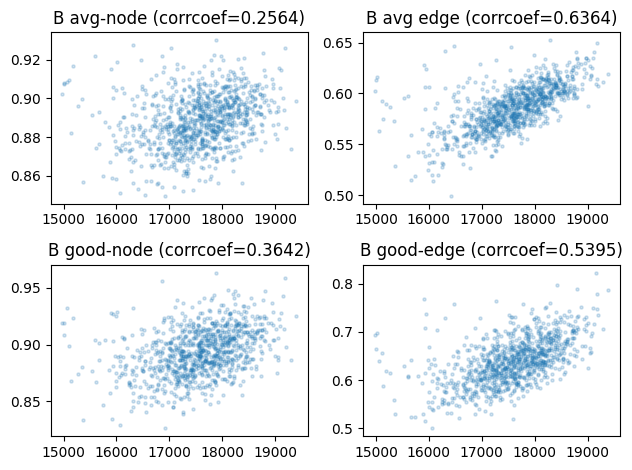

In [59]:
scoresA = [solutions[key][0] for key in a_filtered]
scoresB = [solutions[key][0] for key in b_filtered]

similarities1A = [similarityIndex1[key] / len(solutionNodeSets[key]) for key in a_filtered]
similarities1B = [similarityIndex1[key] / len(solutionNodeSets[key]) for key in b_filtered]
similarities2A = [similarityIndex2[key] / len(solutionEdgeSets[key]) for key in a_filtered]
similarities2B = [similarityIndex2[key] / len(solutionEdgeSets[key]) for key in b_filtered]

goodSimilarities1A = [goodSimilarityIndex1[key] / len(solutionNodeSets[key]) for key in a_filtered]
goodSimilarities1B = [goodSimilarityIndex1[key] / len(solutionNodeSets[key]) for key in b_filtered]
goodSimilarities2A = [goodSimilarityIndex2[key] / len(solutionEdgeSets[key]) for key in a_filtered]
goodSimilarities2B = [goodSimilarityIndex2[key] / len(solutionEdgeSets[key]) for key in b_filtered]

similiaritiesA = {
    "avg-node": similarities1A,
    "avg-edge": similarities2A,
    "good-node": goodSimilarities1A,
    "good-edge": goodSimilarities2A,
}
similiaritiesB = {
    "avg-node": similarities1B,
    "avg edge": similarities2B,
    "good-node": goodSimilarities1B,
    "good-edge": goodSimilarities2B,
}

data = {
    "A" : (scoresA, similiaritiesA),
    "B" : (scoresB, similiaritiesB)
}

for instance, plot_data in data.items():
    x, ys = plot_data
    i = 1
    # plt.figure(figsize=(15,15))
    plt.subplots(2,2)
    for method, y in ys.items():
        corrcoef = np.corrcoef(x, y)[0,1]
        plt.subplot(2,2,i)
        plt.title(f"{instance} {method} (corrcoef={corrcoef:.4f})")
        plt.scatter(x, y, alpha=0.2, s=5)
        i+=1
        plt.tight_layout()
    plt.show()

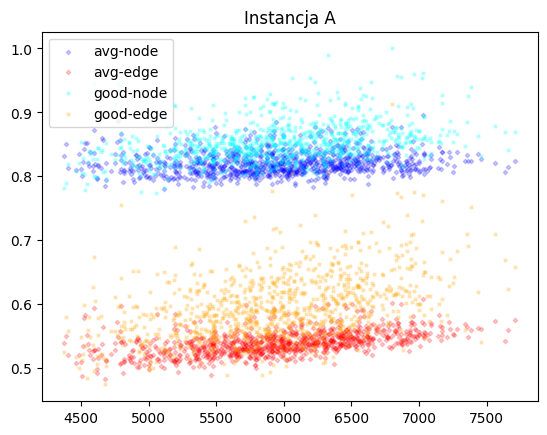

In [60]:
plt.title("Instancja A")
plt.scatter(scoresA, similarities1A, label="avg-node", marker="D", color="blue", alpha=0.2, s=5)
plt.scatter(scoresA, similarities2A, label="avg-edge", marker="D", color="red", alpha=0.2, s=5)
plt.scatter(scoresA, goodSimilarities1A, label="good-node", marker="X", color="cyan", alpha=0.2, s=5)
plt.scatter(scoresA, goodSimilarities2A, label="good-edge", marker="X", color="orange", alpha=0.2, s=5)
plt.legend()

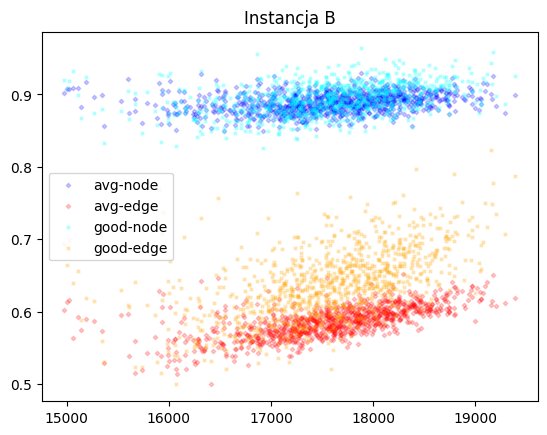

In [61]:
plt.title("Instancja B")
plt.scatter(scoresB, similarities1B, label="avg-node", marker="D", color="blue", alpha=0.2, s=5)
plt.scatter(scoresB, similarities2B, label="avg-edge", marker="D", color="red", alpha=0.2, s=5)
plt.scatter(scoresB, goodSimilarities1B, label="good-node", marker="X", color="cyan", alpha=0.2, s=5)
plt.scatter(scoresB, goodSimilarities2B, label="good-edge", marker="X", color="orange", alpha=0.2, s=5)
plt.legend()